In [1]:
#!pip install 'numpy<2'

If you encounter numpy version issues, you can install a compatible version using the command above.

In [9]:
import numpy as np

import torch
import matplotlib.pyplot as plt

from mmpr.models import REIN
from mmpr.data.utils import getBEV_torch

In [3]:
model = REIN().cuda()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
lidar_path = '/home/docker_mmpr/Datasets/OpenPlaceRec/itlp_campus_indoor/00_2023-10-25-night/floor_1/lidar/1698261906933869394.bin'
lidar_scan = torch.from_numpy(np.fromfile(lidar_path, dtype=np.float32).reshape(-1, 4)[:, :3])

In [45]:
bev_image = getBEV_torch(lidar_scan).float()

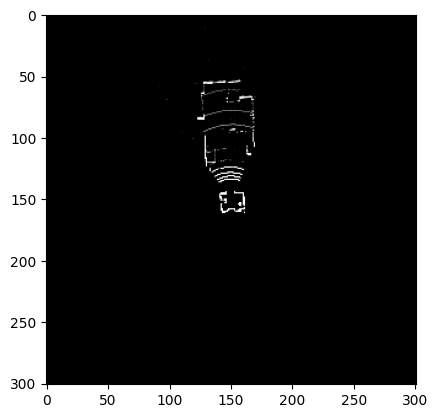

In [46]:
plt.imshow(bev_image.cpu(), cmap='gray')

In [47]:
bev_image.min(), bev_image.max(), bev_image.shape, bev_image.dtype

(tensor(0.), tensor(255.), torch.Size([301, 301]), torch.float32)

In [48]:
bev_image /= 255.0
bev_image = bev_image.unsqueeze(0).repeat(3, 1, 1)

In [49]:
bev_image.shape

torch.Size([3, 301, 301])

In [50]:
model(bev_image.unsqueeze(0).cuda())

(tensor([[[[9.4213e-02, 8.0789e-02, 5.8805e-02,  ..., 6.4223e-02,
            7.9612e-02, 8.6686e-02],
           [8.7205e-02, 7.9841e-02, 6.3976e-02,  ..., 6.7043e-02,
            7.5752e-02, 7.7132e-02],
           [7.1182e-02, 7.1416e-02, 6.2960e-02,  ..., 6.1639e-02,
            6.4465e-02, 6.0455e-02],
           ...,
           [6.0800e-02, 6.1920e-02, 5.6155e-02,  ..., 4.5944e-02,
            5.8399e-02, 6.2452e-02],
           [7.3093e-02, 7.3405e-02, 6.7808e-02,  ..., 6.2748e-02,
            7.0351e-02, 7.2687e-02],
           [7.9229e-02, 7.8110e-02, 7.0456e-02,  ..., 6.9591e-02,
            7.5264e-02, 7.6448e-02]],
 
          [[6.6819e-02, 5.3157e-02, 3.1799e-02,  ..., 6.3518e-02,
            6.5425e-02, 6.2948e-02],
           [6.4458e-02, 5.6720e-02, 4.2147e-02,  ..., 5.8441e-02,
            5.4784e-02, 4.8838e-02],
           [5.6737e-02, 5.7207e-02, 5.2035e-02,  ..., 4.4496e-02,
            3.6712e-02, 2.8114e-02],
           ...,
           [3.2100e-02, 4.4017e-02, 5.